# Figure 5

Environment: env 1

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pickle
import pandas as pd
import seaborn as sns
import os
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from statannotations.Annotator import Annotator
import matplotlib as mpl

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['svg.fonttype'] = 'none'
plt.rcParams["font.family"] = "DejaVu Sans"

# functions

In [2]:

def average_by_subject(df, ids_to_use=None,filename_to_use=None, id_regex=r"(cu\d{4})", average=True):
    """
    If a subject has both eyes, we average their features.

    Args:
        df: df of data
        ids_to_use: ids to apply this to
        filename_to_use: filenames apply this to
        id_regex: the format of the ids
        average: if we ant to combine and average them
    
    Returns:
        df with features averaged by subject.
    """
    df = df.copy()
    if 'id' in df.columns:
        pass
    elif 'file_name' in df.columns:
        df['id'] = df['file_name'].str.extract(id_regex)[0]
    elif 'index' in df.columns:
        df = df.rename(columns={'index': 'file_name'})
        df['id'] = df['file_name'].str.extract(id_regex)[0]
    if ids_to_use is not None:
        df = df[df['id'].isin(ids_to_use)]
    elif filename_to_use is not None:
        if 'file_name' in df.columns:
            df = df[df['file_name'].isin(filename_to_use)]

    if average:

        agg = {c: ('mean' if np.issubdtype(dt, np.number) else 'first')
            for c, dt in df.dtypes.items() if c != 'file_name'}
        g = df.groupby('id', as_index=False).agg(agg)
        g['file_name'] = g['id']
        return g
    else:
        return(df)

In [3]:

def get_pca_df(chosen_df, n_comps=2, get_pca=False, subset_fit=[]):
    if len(subset_fit)>0:
        chosen_df_fit = chosen_df[chosen_df['id'].isin(subset_fit)]
        X_fit = chosen_df_fit.drop(['file_name', 'label', 'id', 'lat'], axis=1, errors='ignore').copy()
        X_fit = X_fit.apply(pd.to_numeric, errors='coerce')        
        X_fit.replace([np.inf, -np.inf], np.nan, inplace=True) 
        X_fit = X_fit.fillna(0)                                    
        # Optional (your original intent): zero tiny values
        X_fit = X_fit.where(X_fit >= 1e-6, 0)
        scaler = StandardScaler()
        chosen_df_scaled_fit = scaler.fit_transform(X_fit)
        n = max(1, min(n_comps, chosen_df_scaled_fit.shape[0], chosen_df_scaled_fit.shape[1]))
        pca = PCA(n_components=n, random_state=0)
        pca.fit(chosen_df_scaled_fit)


    X = chosen_df.drop(['file_name', 'label', 'id', 'lat'], axis=1, errors='ignore').copy()

    # make sure everything going into scaler/PCA is numeric and clean
    X = X.apply(pd.to_numeric, errors='coerce')        
    X.replace([np.inf, -np.inf], np.nan, inplace=True) 
    X = X.fillna(0)                                    
    # Optional (your original intent): zero tiny values
    X = X.where(X >= 1e-6, 0)

    if len(subset_fit)>0:
        chosen_df_scaled = scaler.transform(X)
        chosen_df_scaled = pca.transform(chosen_df_scaled)
    else:
        scaler = StandardScaler()
        chosen_df_scaled = scaler.fit_transform(X)

        # cap n_comps to valid range
        n = max(1, min(n_comps, chosen_df_scaled.shape[0], chosen_df_scaled.shape[1]))
        pca = PCA(n_components=n, random_state=0)
        chosen_df_scaled = pca.fit_transform(chosen_df_scaled)

    # keep your original structure/variable names
    chosen_df_scaled = pd.DataFrame(chosen_df_scaled, index=chosen_df.index)
    chosen_df_scaled['id'] = chosen_df['id'].tolist() if 'id' in chosen_df.columns else None
    chosen_df_scaled['file_name'] = chosen_df['file_name'].tolist() if 'file_name' in chosen_df.columns else None
    chosen_df_scaled['label'] = chosen_df['label'].tolist() if 'label' in chosen_df.columns else None

    chosen_df = chosen_df_scaled
    if get_pca:
        return chosen_df, pca
    else:
        return chosen_df


In [4]:
# remove outliers outside of 4*IQR
def remove_outliers_iqr(df, cols=[], iqr_mult=4):
    cleaned = df.copy()
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - iqr_mult * IQR
        upper = Q3 + iqr_mult * IQR
        cleaned = cleaned[(cleaned[col] >= lower) & (cleaned[col] <= upper)]
        outliers = df[(df[col] < lower) | (df[col] > upper)]['id'].tolist()
    return cleaned, outliers



In [ ]:
def box_plot(input_df, name_map, pw_ids, get_mean=False, file_name=''):
    df = input_df.copy()
    df = df[df['id'].isin(pec_ids + pw_ids)]  # keep relevant subjects


    # Build category mapping (each subject can belong to multiple groups)
    category_map = {
        'PEC': set(pec_ids),
        'HC': set(clean_controls),
        'PW': set(pw_ids),
    }

    # Expand df so that subjects with multiple memberships get duplicated
    df_expanded = []
    for _, row in df.iterrows():
        subject_id = row['id']
        for label, id_set in category_map.items():
            if subject_id in id_set:
                new_row = row.copy()
                new_row['label'] = label
                df_expanded.append(new_row)
    df = pd.DataFrame(df_expanded)

    palette = {'PEC':'#FF0044', 'HC': 'whitesmoke', 'PW':'lightgrey'}

    xval = 'label'
    yval = list(name_map.keys())[0]

    if get_mean:
        if f'{yval}' not in df.columns:
            df[f'{yval}'] = df.filter(like='cu').mean(axis=1)

    fig, ax = plt.subplots(figsize = (2.5, 4), constrained_layout=True)

    df_ = remove_outliers_iqr(df, [yval])[0]
    df_[xval] = df_[xval].replace({0: 'HC', 1:'PEC', 2:'PW'})#, 3:'EOPE', 4:'LOPE'
    sns.boxplot(df_, x=xval, y=yval, showfliers=False, saturation=0.9, palette=palette, order = ['HC','PW', 'PEC'], linecolor="black")
    sns.stripplot(df_, x=xval, y=yval,color='black' , marker="$\circ$", alpha = 0.2, edgecolor='k', linewidth=0.6, order = ['HC','PW', 'PEC'], jitter=0.2, size=4)

    annotator = Annotator(ax = ax, data = df_, x = xval, y = yval, pairs = [('HC','PEC'), ('PW','PEC')], order = ['HC','PW', 'PEC'])
    annotator.hide_non_significant=True
    annotator.configure(test="Mann-Whitney", verbose=False,line_height=0.02, text_offset=-2,text_format='star',use_fixed_offset=10)

    annotator.apply_test()

    annotator.annotate(line_offset_to_group=0.01)

    ax.tick_params(axis='y', which='major', labelsize=9)
    ax.set_xlabel('')
    ax.set_ylabel(name_map[yval])
    if len(file_name)>0:
        fig.savefig(f'figures/{file_name}.png', transparent=True, dpi=300, bbox_inches='tight')   
    else:
        fig.savefig(f'figures/fig3_{yval}_color.pdf', transparent=True, dpi=300, bbox_inches='tight')

In [ ]:
def prepare_feature_catalog(
    case_file, control_file, clinical_file,
    id_regex=r"(cu\d{4})", average=True, feature_folder="all_features", pre="all", post=""
):
    """
    Loads all tables, builds subject-level aggregates, merges clinical/bins, defines feature groups:
      - dfs, ks_dfs, pca_dfs (lists of feature *names*)
      - dfs_map, ks_dfs_map, pca_dfs_map (name -> DataFrame)
      - dfs_set, ks_dfs_set, pca_dfs_set (sets of names)
      - df_use (with labels)
    """

    # base labels / subject filtering 
    df_results_all = pd.read_csv(os.path.join(feature_folder, f"{pre}_graph_feats_processed{post}.csv"))
    df_results_all['id'] = df_results_all['id'].astype(str).str.lower()


    with open(case_file, "rb") as f:
        case_group = pickle.load(f)

    with open(control_file, "rb") as f:
        control_group = pickle.load(f)

    case_group = [x.lower() for x in case_group]
    control_group = [x.lower() for x in control_group]

    # df_use = df_results_all[df_results_all['id'].isin(case_group + control_group)].copy()
    df_use = df_results_all.copy()
    df_use['label'] = df_use['id'].apply(lambda x: 1 if x in case_group else 0)
    df_use = df_use.dropna()

    # load features
    graph_feats = df_use.copy()

    bins_feats = pd.read_csv(os.path.join(feature_folder, f"{pre}_tree_feats_old_processed{post}.csv"))
    bins_feats['id'] = bins_feats['file_name'].str.extract(id_regex)[0]

    clinical_feats = pd.read_csv(clinical_file, index_col=0)
    clinical_feats['Study ID'] = clinical_feats['Study ID'].str.lower()

    box_counting_df = pd.read_csv(os.path.join(feature_folder, f"{pre}_box_counting{post}.csv"))
    tda_vr          = pd.read_csv(os.path.join(feature_folder, f"{pre}_tda_VR{post}.csv"))
    tda_inward      = pd.read_csv(os.path.join(feature_folder, f"{pre}_tda_inward{post}.csv"))
    tda_outward     = pd.read_csv(os.path.join(feature_folder, f"{pre}_tda_outward{post}.csv"))
    tda_flooding    = pd.read_csv(os.path.join(feature_folder, f"{pre}_tda_flooding{post}.csv"))

    tree_feats_len_top        = pd.read_csv(os.path.join(feature_folder, f"{pre}_tree_feats_lengths_top{post}.csv"))
    tree_feats_len_real_top   = pd.read_csv(os.path.join(feature_folder, f"{pre}_tree_feats_lengths_real_top{post}.csv"))
    tree_feats_conductivity_top = pd.read_csv(os.path.join(feature_folder, f"{pre}_tree_feats_conductivity_top{post}.csv"))
    tree_feats_len_bottom     = pd.read_csv(os.path.join(feature_folder, f"{pre}_tree_feats_lengths_bottom{post}.csv"))
    tree_feats_len_real_bottom = pd.read_csv(os.path.join(feature_folder, f"{pre}_tree_feats_lengths_real_bottom{post}.csv"))
    tree_feats_conductivity_bottom = pd.read_csv(os.path.join(feature_folder, f"{pre}_tree_feats_conductivity_bottom{post}.csv"))

    old_tree_feats_len       = pd.read_csv(os.path.join(feature_folder, f"{pre}_tree_feats_old_lengths{post}.csv"))
    old_tree_feats_assymetry = pd.read_csv(os.path.join(feature_folder, f"{pre}_tree_feats_old_Asymmetry{post}.csv"))
    old_tree_feats_diameter  = pd.read_csv(os.path.join(feature_folder, f"{pre}_tree_feats_old_diameters{post}.csv"))

    # processed_dan_tree_feats = pd.read_csv(os.path.join(feature_folder, f"all_t1_tree_feats_dan_processed.csv")) ## need to be changed if using new!
    processed_dan_tree_feats = pd.read_csv(os.path.join(feature_folder, f"{pre}_tree_feats_processed{post}.csv")) 


    graph_feats = graph_feats.merge(processed_dan_tree_feats, left_on='file_name', right_on='index', how='outer')
    bins_feats = graph_feats.merge(bins_feats, on='file_name', suffixes=['dan',''])

    clinical_feats['id'] = clinical_feats['Study ID'].str.lower()
    clinical_feats['file_name'] = clinical_feats['id']
    clinical_feats['label'] = [1 if x in case_group else 0 for x in clinical_feats['id']]



    # column groups 
    required = ['file_name', 'label', 'id']

    bifurc_ratio_feats    = [f'bifurc_ratio_{n}' for n in range(2, 4)]
    strahler_order_feats  = [f'strahler_order_counts_{n}' for n in range(1, 6)]
    graph_cols            = ['num_nodes','num_components','n_edge_nodes','n_branches','direct_dist']
    tort_cols             = ['sinuosity_all','dic_tort','tort_density','linreg_tort','sq_curvature_tortuosity','abs_curvature_tortuosity']
    complexity_cols       = ['loops','fds']
    asym_feats            = ['avg_asymmetry','sum_asymmetry','q25_asymmetry','q50_asymmetry','q75_asymmetry','q100_asymmetry']
    cum_size_dist_feats   = ['avg_cumulative_size_dist','sum_cumulative_size_dist','q25_cumulative_size_dist','q50_cumulative_size_dist','q75_cumulative_size_dist','q100_cumulative_size_dist']
    topo_lengths_feats    = ['avg_topo_length_top','avg_topo_length_bottom','median_topo_length_top','median_topo_length_bottom',
                             'avg_topo_length_weight_top','avg_topo_length_weight_bottom','median_topo_length_weight_top','median_topo_length_weight_bottom']
    topo_lengths_feats_dan= ['avg_topo_length_top_dan','avg_topo_length_bottom_dan','median_topo_length_top_dan','median_topo_length_bottom_dan',
                             'avg_topo_length_weight_top_dan','avg_topo_length_weight_bottom_dan','median_topo_length_weight_top_dan','median_topo_length_weight_bottom_dan']
    nest_num_feats        = ['nest_num_unw','nest_num_w','avg_nest_ratios','avg_nest_ratios_w','sum_nest_ratios','sum_nest_ratios_w']
    nest_num_feats_dan    = ['nest_num_unw_dan','nest_num_w_dan','avg_nest_ratios_dan','avg_nest_ratios_w_dan','sum_nest_ratios_dan','sum_nest_ratios_w_dan']
    tree_feats      = ['tree_depth','tree_leaves']
    geom_feats            = ['vein_density_len','mean_vein_distances','mean_areole_area','areole_density']
    angle_feats           = ['avg_angle','median_angle','sum_angle','beta']
    angle_feats_dan       = ['avg_angle_dan','median_angle_dan','sum_angle_dan']
    conductivity_feats    = ['avg_conductivities_top','median_conductivities_top','avg_conductivities_bottom','median_conductivities_bottom']
    ratio_feats           = ['avg_topo_length_weight_topbottom_ratio','avg_topo_length_topbottom_ratio',
                             'avg_conductivities_topbottom_ratio','median_conductivities_topbottom_ratio',
                             'median_topo_length_weight_topbottom_ratio','median_topo_length_topbottom_ratio']
    std_feats             = ['std_asymmetry','std_cumulative_size_dist','std_topo_length_top','std_topo_length_bottom',
                             'std_topo_length_weight_top','std_topo_length_weight_bottom','std_conductivities_top','std_conductivities_bottom',
                             'std_nest_ratios','std_nest_ratios_w','std_angle']
    clinical_feats_base   = ['Age at enrollment','Current Smoker','Former Smoker','Past Preeclampsia','IVF','Maternal hispanic',
                             'Maternal Race_Asian','Maternal Race_Black','Maternal Race_Multiracial','Maternal Race_Other',
                             'Maternal Race_Unknown','Maternal Race_White']
    clinical_feats_extra2 = ['ama_custom','Past Gestational HTN','Past Gestational diabetes','Past Hypertension']
    clinical_feats_extra = ['ama', 'gestationaldiabetes', 'obesity', 'aspirin', 'bp_meds', 'insulin']

    all_clinical_feats = ['Age at enrollment','Current Smoker','Former Smoker','Past Preeclampsia','Past Gestational HTN','Past Gestational diabetes','Past Hypertension',
                          'IVF','Maternal hispanic','Maternal Race_Asian','Maternal Race_Black','Maternal Race_Multiracial','Maternal Race_Other',
                             'Maternal Race_Unknown','Maternal Race_White', 'obesity']
    
    fmf_clinical_feats = ['Age at enrollment', 'Current Smoker', 'Past Preeclampsia',
       'IVF', 'Insulin?', 'Maternal hispanic',
       'Maternal Race_Asian', 'Maternal Race_Black',
       'Maternal Race_Multiracial', 'Maternal Race_Other',
       'Maternal Race_Unknown', 'Maternal Race_White',
       'Cardiac Hypertensive Disease', 'Diabetes_type1', 'Diabetes_type2',
       'Past Gestational diabetes', 'Past Preterm Labor', 'nulliparous']
    
    mixed_feat_set = ['n_branches','direct_dist','sq_curvature_tortuosity','loops','fds','avg_topo_length_top_dan','avg_topo_length_bottom_dan']
    # clinical_feats_extra2 = ['ama', 'obesity', 'Diabetes', 'Past Gestational HTN', 'Past Gestational diabetes', 'Past Hypertension']

    # append required
    def add_req(lst): return lst + required
    graph_cols              = add_req(graph_cols)
    tort_cols               = add_req(tort_cols)
    complexity_cols         = add_req(complexity_cols)
    asym_feats              = add_req(asym_feats)
    cum_size_dist_feats     = add_req(cum_size_dist_feats)
    bifurc_ratio_feats      = add_req(bifurc_ratio_feats)
    strahler_order_feats    = add_req(strahler_order_feats)
    topo_lengths_feats      = add_req(topo_lengths_feats)
    topo_lengths_feats_dan  = add_req(topo_lengths_feats_dan)
    nest_num_feats          = add_req(nest_num_feats)
    nest_num_feats_dan      = add_req(nest_num_feats_dan)
    tree_feats        = add_req(tree_feats)
    geom_feats              = add_req(geom_feats)
    angle_feats             = add_req(angle_feats)
    angle_feats_dan         = add_req(angle_feats_dan)
    conductivity_feats      = add_req(conductivity_feats)
    ratio_feats             = add_req(ratio_feats)
    clinical_feats_base     = add_req(clinical_feats_base)
    clinical_feats_extra2   = add_req(clinical_feats_extra2)
    clinical_feats_extra   = add_req(clinical_feats_extra)
    all_clinical_feats   = add_req(all_clinical_feats)
    fmf_clinical_feats   = add_req(fmf_clinical_feats)
    std_feats               = add_req(std_feats)
    mixed_feat_set = add_req(mixed_feat_set)

    # subject-level aggregation (average)
    file_name_to_use = set(df_use['file_name'].unique())
    ids_to_use = set(df_use['id'].unique())

    box_counting_df = average_by_subject(box_counting_df, filename_to_use=file_name_to_use, id_regex=id_regex, average=average)
    tda_vr          = average_by_subject(tda_vr, filename_to_use=file_name_to_use, id_regex=id_regex, average=average)
    tda_inward      = average_by_subject(tda_inward, filename_to_use=file_name_to_use, id_regex=id_regex, average=average)
    tda_outward     = average_by_subject(tda_outward, filename_to_use=file_name_to_use, id_regex=id_regex, average=average)
    tda_flooding    = average_by_subject(tda_flooding, filename_to_use=file_name_to_use, id_regex=id_regex, average=average)
    graph_feats     = average_by_subject(graph_feats, filename_to_use=file_name_to_use, id_regex=id_regex, average=average)
    old_tree_feats_len       = average_by_subject(old_tree_feats_len, filename_to_use=file_name_to_use, id_regex=id_regex, average=average)
    old_tree_feats_assymetry = average_by_subject(old_tree_feats_assymetry, filename_to_use=file_name_to_use, id_regex=id_regex, average=average)
    old_tree_feats_diameter  = average_by_subject(old_tree_feats_diameter, filename_to_use=file_name_to_use, id_regex=id_regex, average=average)
    tree_feats_len_top       = average_by_subject(tree_feats_len_top, filename_to_use=file_name_to_use, id_regex=id_regex, average=average)
    tree_feats_len_real_top  = average_by_subject(tree_feats_len_real_top, filename_to_use=file_name_to_use, id_regex=id_regex, average=average)
    tree_feats_conductivity_top = average_by_subject(tree_feats_conductivity_top, filename_to_use=file_name_to_use, id_regex=id_regex, average=average)
    tree_feats_len_bottom    = average_by_subject(tree_feats_len_bottom, filename_to_use=file_name_to_use, id_regex=id_regex, average=average)
    tree_feats_len_real_bottom = average_by_subject(tree_feats_len_real_bottom, filename_to_use=file_name_to_use, id_regex=id_regex, average=average)
    tree_feats_conductivity_bottom = average_by_subject(tree_feats_conductivity_bottom, filename_to_use=file_name_to_use, id_regex=id_regex, average=average)
    processed_dan_tree_feats = average_by_subject(processed_dan_tree_feats, filename_to_use=file_name_to_use, id_regex=id_regex, average=average)
    processed_dan_tree_feats['label'] = processed_dan_tree_feats['id'].apply(lambda x: 1 if x in case_group else 0)   


    dfs = [
        'graph_feats[mixed_feat_set]','graph_feats[graph_cols]','graph_feats[tort_cols]','graph_feats[complexity_cols]',
        'bins_feats[asym_feats]','bins_feats[cum_size_dist_feats]','bins_feats[bifurc_ratio_feats]',
        'bins_feats[strahler_order_feats]','bins_feats[topo_lengths_feats]',
        'processed_dan_tree_feats[topo_lengths_feats_dan]','bins_feats[nest_num_feats]',
        'processed_dan_tree_feats[nest_num_feats_dan]','bins_feats[tree_feats]',
        'bins_feats[geom_feats]',
        'processed_dan_tree_feats[angle_feats_dan]','bins_feats[conductivity_feats]',
        'bins_feats[ratio_feats]','bins_feats[std_feats]',
        'clinical_feats[all_clinical_feats]'
    ]
    ks_dfs  = ['tree_feats_len_top','tree_feats_len_real_top','tree_feats_conductivity_top',
               'tree_feats_len_bottom','tree_feats_len_real_bottom','tree_feats_conductivity_bottom',
               'old_tree_feats_len','old_tree_feats_assymetry','old_tree_feats_diameter']
    pca_dfs = ['box_counting_df','tda_vr','tda_inward','tda_outward','tda_flooding']

    # dataframes by base name
    frames = {
        'graph_feats': graph_feats,
        'processed_dan_tree_feats': processed_dan_tree_feats,
        'bins_feats': bins_feats,
        'box_counting_df': box_counting_df,
        'tda_vr': tda_vr,
        'tda_inward': tda_inward,
        'tda_outward': tda_outward,
        'tda_flooding': tda_flooding,
        'tree_feats_len_top': tree_feats_len_top,
        'tree_feats_len_real_top': tree_feats_len_real_top,
        'tree_feats_conductivity_top': tree_feats_conductivity_top,
        'tree_feats_len_bottom': tree_feats_len_bottom,
        'tree_feats_len_real_bottom': tree_feats_len_real_bottom,
        'tree_feats_conductivity_bottom': tree_feats_conductivity_bottom,
        'old_tree_feats_len': old_tree_feats_len,
        'old_tree_feats_assymetry': old_tree_feats_assymetry,
        'old_tree_feats_diameter': old_tree_feats_diameter,
        'clinical_feats':clinical_feats
    }
    # column groups by feature set name
    colsets = {
        'mixed_feat_set':mixed_feat_set,'graph_cols': graph_cols, 'tort_cols': tort_cols, 'complexity_cols': complexity_cols,
        'asym_feats': asym_feats, 'cum_size_dist_feats': cum_size_dist_feats,
        'bifurc_ratio_feats': bifurc_ratio_feats, 'strahler_order_feats': strahler_order_feats,
        'topo_lengths_feats': topo_lengths_feats, 'topo_lengths_feats_dan': topo_lengths_feats_dan,
        'nest_num_feats': nest_num_feats, 'nest_num_feats_dan': nest_num_feats_dan,
        'tree_feats': tree_feats, 'geom_feats': geom_feats,
        'angle_feats': angle_feats, 'angle_feats_dan': angle_feats_dan,
        'conductivity_feats': conductivity_feats, 'ratio_feats': ratio_feats,
        'std_feats': std_feats,
        'all_clinical_feats': all_clinical_feats
    }

    # Build maps consistent with string keys you already use
    dfs_map = {}
    for name in dfs:
        if '[' in name:        # e.g., 'graph_feats[graph_cols]'
            base, cols = name.split('[', 1)
            base = base.strip()
            cols = cols.rstrip(']').strip()
            dfs_map[name] = frames[base][colsets[cols]].copy()
        else:
            dfs_map[name] = frames[name].copy()

    ks_dfs_map  = {name: frames[name].copy() for name in ks_dfs}
    pca_dfs_map = {name: frames[name].copy() for name in pca_dfs}

    df_use = df_use[['id','label']].drop_duplicates()

    return {
        "df_use": df_use,
        "dfs": dfs, "ks_dfs": ks_dfs, "pca_dfs": pca_dfs,
        "dfs_map": dfs_map, "ks_dfs_map": ks_dfs_map, "pca_dfs_map": pca_dfs_map,
        "dfs_set": set(dfs), "ks_dfs_set": set(ks_dfs), "pca_dfs_set": set(pca_dfs),
    }

# load data

In [5]:
# initialize paths

dropbox_path = "C:\\Users\\ds7014\\NYU Langone Health Dropbox\\Daniel Sunko/Shenhav_lab/Visionary_AI"


full_dataset_path = os.path.join(dropbox_path,'code_data/Data/columbia')

cohort_pickles_path = os.path.join(full_dataset_path,'cohort_pickles')

# data_name = 'pec_hc'
data_name = 'features_all'
results_folder = os.path.join(full_dataset_path,data_name)

# pw_folder = os.path.join(full_dataset_path,'data_pop_wide')



control_file = os.path.join(cohort_pickles_path, 'final_hc_20251017.pkl')
clinical_file = os.path.join(full_dataset_path, 'clinical_features_all_20250930.csv')

n_comps = 10

clean_controls = pd.read_pickle(control_file)
clean_controls = [x.lower() for x in clean_controls]


In [6]:
case_file_pec = os.path.join(cohort_pickles_path, 'final_pec_20251017.pkl')
pec_ids = pd.read_pickle(case_file_pec)
pec_ids = [x.lower() for x in pec_ids]
pec_ids = list(set(pec_ids+['cu0776']))

ght_cases = pd.read_pickle(os.path.join(cohort_pickles_path,'ght_cases_20250926.pkl'))
ght_cases = [x.lower() for x in ght_cases]
cht_cases = pd.read_pickle(os.path.join(cohort_pickles_path,'cht_cases_20250926.pkl'))
cht_cases = [x.lower() for x in cht_cases]

In [8]:
pc_pec = prepare_feature_catalog(
    feature_folder=results_folder,
    pre='final_all',
    post='_2025-10-16',
    # data_name='all',
    case_file=case_file_pec,
    control_file=control_file,
    clinical_file=clinical_file,
    id_regex=r"(cu\d{4})",   
)

df_use_pec      = pc_pec["df_use"]
dfs_pec         = pc_pec["dfs"]
ks_dfs_pec      = pc_pec["ks_dfs"]
pca_dfs_pec     = pc_pec["pca_dfs"]
dfs_map_pec     = pc_pec["dfs_map"]
ks_dfs_map_pec  = pc_pec["ks_dfs_map"]
pca_dfs_map_pec = pc_pec["pca_dfs_map"]
dfs_set_pec     = pc_pec["dfs_set"]
ks_dfs_set_pec  = pc_pec["ks_dfs_set"]
pca_dfs_set_pec = pc_pec["pca_dfs_set"]

catalog_pec = {}
catalog_pec.update(pc_pec["dfs_map"])
catalog_pec.update(pc_pec["ks_dfs_map"])
catalog_pec.update(pc_pec["pca_dfs_map"])

dfs_set_pec     = pc_pec["dfs_set"]
ks_dfs_set_pec  = pc_pec["ks_dfs_set"]
pca_dfs_set_pec = pc_pec["pca_dfs_set"]

feature_dicts_all_pec = {
    "dfs":     [fs for fs in dfs_set_pec],
    "ks_dfs":  [fs for fs in ks_dfs_set_pec],
    "pca_dfs": [fs for fs in pca_dfs_set_pec],
}

y_df_pec = pc_pec['df_use'][['id','label']].drop_duplicates()

In [9]:
pw1_stable = pd.read_pickle(os.path.join(cohort_pickles_path, 'rev_strat_hc_pw1_controls_20260403.pkl'))
pw2_stable = pd.read_pickle(os.path.join(cohort_pickles_path, 'rev_strat_hc_pw2_controls_20260403.pkl'))
pw3_stable = pd.read_pickle(os.path.join(cohort_pickles_path, 'rev_strat_hc_pw3_controls_20260403.pkl'))
pw4_stable = pd.read_pickle(os.path.join(cohort_pickles_path, 'rev_strat_hc_pw4_controls_20260403.pkl'))
pw5_stable = pd.read_pickle(os.path.join(cohort_pickles_path, 'rev_strat_hc_pw5_controls_20260403.pkl'))
pw_stable = pw1_stable+pw2_stable+pw3_stable+pw4_stable+pw5_stable

# boxplots

### graph feats

C:\Users\ds7014\AppData\Local\Temp\ipykernel_37768\958868905.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(df_, x=xval, y=yval, showfliers=False, saturation=0.9, palette=palette, order = ['HC','PW', 'PEC'], linecolor="black")


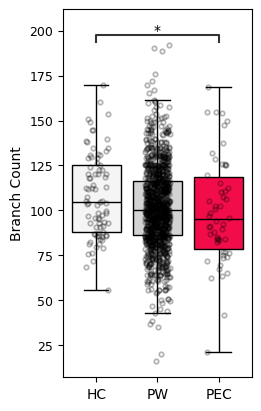

In [12]:
box_plot(dfs_map_pec['graph_feats[graph_cols]'],{'n_branches':'Branch Count'}, pw_ids = pw_stable,file_name='branch_count_052626' )

### tortuosity feats

C:\Users\ds7014\AppData\Local\Temp\ipykernel_37768\958868905.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(df_, x=xval, y=yval, showfliers=False, saturation=0.9, palette=palette, order = ['HC','PW', 'PEC'], linecolor="black")


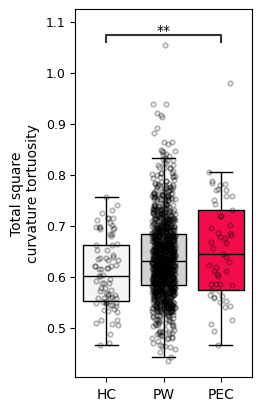

In [14]:
box_plot(dfs_map_pec['graph_feats[tort_cols]'],{'sq_curvature_tortuosity':'Total square\ncurvature tortuosity'}, pw_ids = pw_stable,file_name='sq_tort_052626')

### nesting tree features

C:\Users\ds7014\AppData\Local\Temp\ipykernel_37768\958868905.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(df_, x=xval, y=yval, showfliers=False, saturation=0.9, palette=palette, order = ['HC','PW', 'PEC'], linecolor="black")


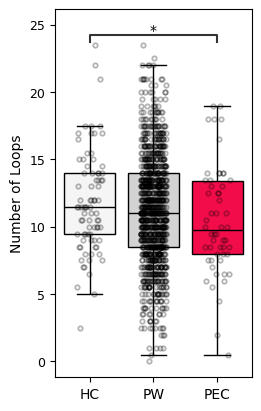

In [15]:
box_plot(dfs_map_pec['graph_feats[complexity_cols]'],{'loops':'Number of Loops'}, pw_ids = pw_stable,file_name='num_loops_052626')

### ks topological length weighted bottom: Fig 5

C:\Users\ds7014\AppData\Local\Temp\ipykernel_37768\958868905.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(df_, x=xval, y=yval, showfliers=False, saturation=0.9, palette=palette, order = ['HC','PW', 'PEC'], linecolor="black")


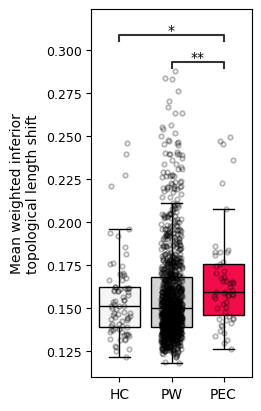

In [17]:
box_plot(ks_dfs_map_pec['tree_feats_len_real_bottom'],{'tree_feats_len_real_bottom_mean':'Mean weighted inferior\ntopological length shift'}, get_mean=True,pw_ids = pw_stable,file_name='tree_feats_len_real_bottom_052626')

### pca box counting: Fig 5

In [18]:
pc_temp = get_pca_df(pca_dfs_map_pec['box_counting_df'],n_comps=10)

C:\Users\ds7014\AppData\Local\Temp\ipykernel_37768\958868905.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(df_, x=xval, y=yval, showfliers=False, saturation=0.9, palette=palette, order = ['HC','PW', 'PEC'], linecolor="black")


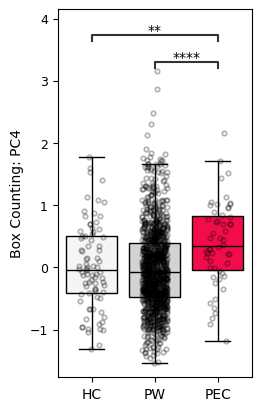

In [19]:
box_plot(pc_temp,{3:'Box Counting: PC4'}, pw_ids = pw_stable,file_name='box_counting_pc4_052626' )